# STEP 3. EDA & Analysis

### 1. 분석 목적 및 최종 질문
- 본 분석에서는 전처리된 스타벅스 앱 행동 로그를 활용하여  
오퍼를 받은 고객이 실제 행동(조회, 완료, 결제)으로  
이어지는 과정에서의 병목 지점을 확인하고 그 병목의 원인이 고객의 문제인지 오퍼의 문제인지 타이밍/경험의 문제인지를 탐색한다.   
---


### 2. 데이터 로드 및 개요


In [7]:
# 환경 설정 및 데이터 로드

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#한글깨짐 방지
plt.rcParams['font.family'] = 'AppleGothic'  # 한글지원하는 폰트를 기본으로 교체
plt.rcParams['axes.unicode_minus'] = False    #음수기호 깨짐 방지

df = pd.read_csv('../data/processed/transcript_preprocessed.csv')

df.head()

,person,event,value,time,offer_id,reward,amount
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN



---
### 3. 전체 이벤트 분포


In [8]:
#3-1. 이벤트 종류 확인
df['event'].value_counts()

event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579
Name: count, dtype: int64

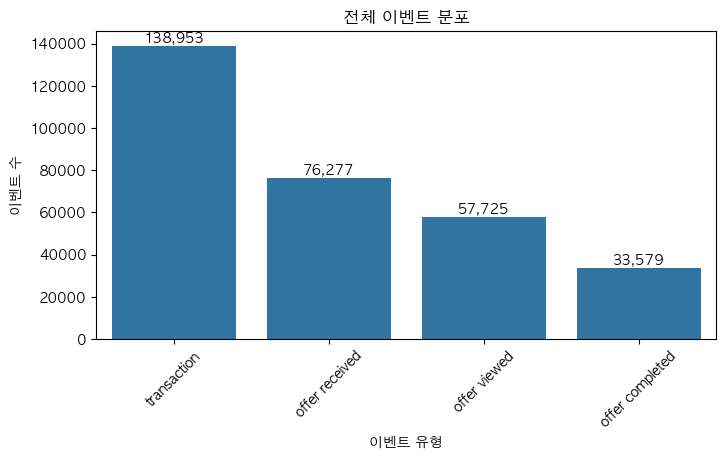

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns  # ✅ 이거 빠지면 NameError 남

# 3-1. 전체 이벤트 분포 시각화 (숫자 표시)
event_counts = df['event'].value_counts().reset_index()
event_counts.columns = ['event', 'count']

# ✅ 혹시라도 문자열로 들어갔을 때 대비
event_counts['count'] = event_counts['count'].astype(int)

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=event_counts, x='event', y='count')

plt.title('전체 이벤트 분포')
plt.xlabel('이벤트 유형')
plt.ylabel('이벤트 수')
plt.xticks(rotation=45)

# ✅ 막대 위 숫자 표시
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        h,
        f"{int(h):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        clip_on=False
    )


plt.show()

📌 Insight

- 전체 행동 로그는 거래(구매 행동)와 오퍼 관련 이벤트(수신, 조회, 완료 순)로 구성되어 있다.
- 이는 스타벅스 앱에서 오퍼가 단순한 마케팅 수단이 아니라, 사용자 행동 유도 수단임을 알 수 있음. (프로덕트 사용 로그에 가까워 보임)
- 오퍼를 받는 것 대비 끝까지 완료되는 경우가 줄어듬 (오퍼 반응 과정에서 이탈이 발생)
- 따라서 고객의 오퍼 반응 과정을 단계별 전환율을 분석하는 퍼널 접근으로 분석하는 것이 필요해 보임.

---
### 4. 오퍼 라이프사이클 관점 분석
- 그렇다면 오퍼는 실제 어떻게 소비되고 있을까?

In [18]:
#4.1 오퍼이벤트만 추출 
offer_events = df[df['event'].isin([
    'offer received',
    'offer viewed',
    'offer completed'
])]

In [19]:
#4.2 단계별 이벤트 수 비교
offer_event_counts = (
    offer_events['event']
    .value_counts()
    .reset_index()
)
offer_event_counts.columns = ['event', 'count']

offer_event_counts

,event,count
0,offer received,76277
1,offer viewed,57725
2,offer completed,33579


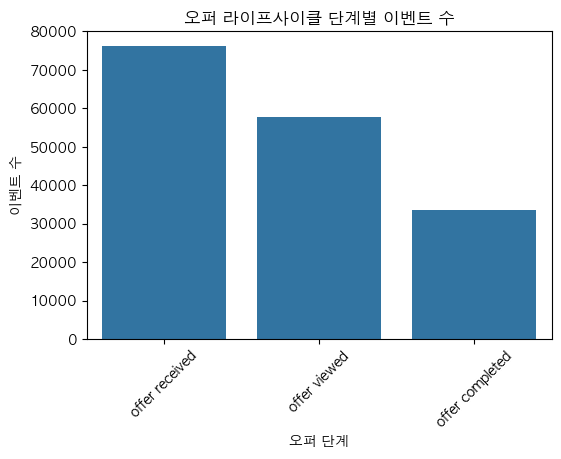

In [14]:
plt.figure(figsize=(6, 4))
sns.barplot(data=offer_event_counts, x='event', y='count')
plt.title('오퍼 라이프사이클 단계별 이벤트 수')
plt.xlabel('오퍼 단계')
plt.ylabel('이벤트 수')
plt.xticks(rotation=45)
plt.show()

In [15]:
offer_event_counts['percentage'] = (
    offer_event_counts['count'] 
    / offer_event_counts.loc[
        offer_event_counts['event'] == 'offer received', 'count'
    ].values[0]
) * 100

offer_event_counts

,event,count,percentage
0,offer received,76277,100.000000
1,offer viewed,57725,75.678121
2,offer completed,33579,44.022445


In [16]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

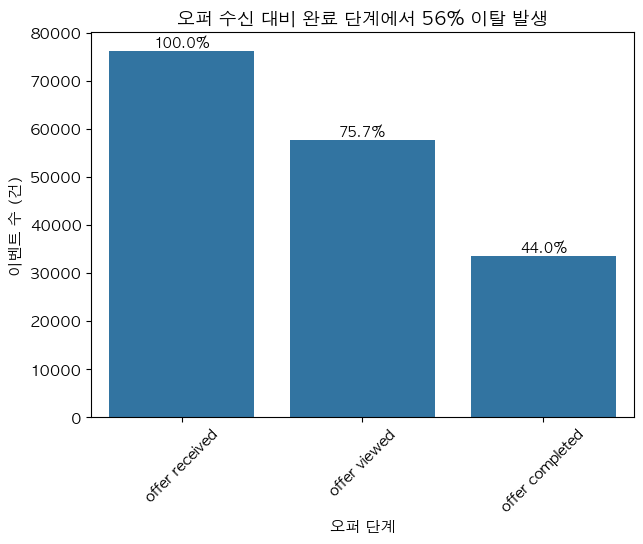

In [17]:
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=offer_event_counts,
    x='event',
    y='count'
)

plt.title('오퍼 수신 대비 완료 단계에서 56% 이탈 발생')
plt.xlabel('오퍼 단계')
plt.ylabel('이벤트 수 (건)')
plt.xticks(rotation=45)

# 퍼센트 라벨 (소수 1자리)
for i, row in offer_event_counts.iterrows():
    ax.text(
        i,
        row['count'],
        f"{row['percentage']:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()

📌 Insight

- 오퍼 수신 → 조회 → 완료 단계로 갈수록
  이벤트 수가 단계적으로 감소하는 패턴이 확인된다.
- 오퍼를 수신한 고객 대비 실제 완료 단계까지 도달하는 비율은 약 44%에 불과하다.
- 특히 Offer Viewed → Offer Completed 단계에서 가장 큰 이탈이 발생한다.

### 🔍 퍼널 전환 분석 요약

- 오퍼 수신 대비 완료 전환율은 약 44%로 낮은 수치이다. (그럼 왜 56%는 오퍼를 받고도 이탈할까?)
- 가장 큰 병목 (75.7% -> 44.0%로 약 이전 단계의 41.9% 이탈) 은 Offer Viewed → Offer Completed 구간(보고나서 그냥 이탈)이다.
- 다음 단계에서는 이 병목이 특정 고객군에서 더 크게 발생하는지 확인한다.

---
### 5. 고객 행동 기반 세그먼트 분석
- 어떤 유형의 고객이 어느 단계에서 멈추는가를 식별할 수 있도록



In [20]:
#6.1 오퍼 이벤트만 필터
offer_df = df[df['event'].isin([
    'offer received', 'offer viewed', 'offer completed'
])]

#6.2 person-offer 기준으로 단계 여부 집계
person_offer = (
    offer_df
    .pivot_table(
        index=['person', 'offer_id'],
        columns='event',
        values='time',
        aggfunc='min'
    )
    .reset_index()
)

person_offer.head()


event,person,offer_id,offer completed,offer received,offer viewed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576.0,576.0,NaN
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,NaN,336.0,372.0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,NaN,168.0,192.0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414.0,408.0,456.0
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528.0,504.0,540.0


한 고객이 여러 오퍼 받을 수 있음 -> 중복 등장 가능
같은 오퍼 아이디가 여러 고객에게 갔을 수 있음 -> 중복 등장 가능
3️⃣ offer_received (숫자 의미 = 리워드 프로그램에 가입한 시점으로부터의 경과 시간)
	•	이 고객이 이 오퍼를 처음 받은 시점(time)
    4️⃣ offer_viewed
	•	이 고객이 이 오퍼를 열어본 최초 시점
	•	NaN이면?
	•	👉 받긴 했지만 열어보지 않음
    5️⃣ offer_completed
	•	이 고객이 이 오퍼를 완료한 최초 시점
	•	NaN이면?
	•	👉 열어봤지만 완료하지 않음

In [23]:
#단계 통과에 대한 boolean 값 생성
person_offer['received'] = person_offer['offer received'].notnull()
person_offer['viewed'] = person_offer['offer viewed'].notnull()
person_offer['completed'] = person_offer['offer completed'].notnull()

person_offer[['received', 'viewed', 'completed']].head()

event,received,viewed,completed
0,True,False,True
1,True,True,False
2,True,True,False
3,True,True,True
4,True,True,True


In [24]:
#어디서 이탈했는지 확인
def dropoff_stage(row):
    if row['completed']:
        return 'Completed'
    elif row['received'] and not row['viewed']:
        return 'Received → Viewed 이탈'
    elif row['viewed'] and not row['completed']:
        return 'Viewed → Completed 이탈'
    else:
        return '기타'

person_offer['dropoff_stage'] = person_offer.apply(dropoff_stage, axis=1)

---
### 7. 고객 속성 결합 및 이탈 가능성 탐색 



In [25]:
# profile 데이터 붙이기
profile = pd.read_json(
    '../data/raw/profile.json',
    orient='records',
    lines=True
)

person_offer_profile = person_offer.merge(
    profile,
    left_on='person',
    right_on='id',
    how='left'
)

person_offer_profile.head()

,person,offer_id,offer completed,offer received,offer viewed,received,viewed,completed,dropoff_stage,gender,age,id,became_member_on,income
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576.0,576.0,NaN,True,False,True,Completed,M,33,0009655768c64bdeb2e877511632db8f,20170421,72000.0
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,NaN,336.0,372.0,True,True,False,Viewed → Completed 이탈,M,33,0009655768c64bdeb2e877511632db8f,20170421,72000.0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,NaN,168.0,192.0,True,True,False,Viewed → Completed 이탈,M,33,0009655768c64bdeb2e877511632db8f,20170421,72000.0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414.0,408.0,456.0,True,True,True,Completed,M,33,0009655768c64bdeb2e877511632db8f,20170421,72000.0
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528.0,504.0,540.0,True,True,True,Completed,M,33,0009655768c64bdeb2e877511632db8f,20170421,72000.0


In [26]:
#7.1 속성 조합 보기 전 연령대 그룹화
person_offer_profile['age_group'] = pd.cut(
    person_offer_profile['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+']
)

In [42]:
#7.2 소득 구간 나누기 전 소득 분포 먼저 확인
person_offer_profile['income'].isna().mean()
person_offer_profile['income'].describe()

count     55222.000000
mean      65388.595125
std       21626.373809
min       30000.000000
25%       49000.000000
50%       63000.000000
75%       80000.000000
max      120000.000000
Name: income, dtype: float64

In [43]:
# ✅ 7.2 소득 구간화 (분포 기반: 사분위수 경계 사용)
# - 왜 이걸 하냐? income(연소득)을 "상대적 소득 수준"으로 나눠서
#   이후 이탈률/완료율을 Low~High 그룹 간 비교 가능하게 만들기 위함.
# - 구간 기준은 데이터의 사분위수(Q1, Q2, Q3)를 경계로 사용한다.
#   (현재 describe()에서 확인한 값: Q1=49,000 / Q2=63,000 / Q3=80,000)

# 1) 사분위 경계값(근거) 저장: 보고서에 그대로 적기 좋게 숫자를 고정해둠
q1, q2, q3 = person_offer_profile["income"].quantile([0.25, 0.50, 0.75]).tolist()
print(f"소득 사분위 경계값: Q1={q1:,.0f}, Q2={q2:,.0f}, Q3={q3:,.0f}")

# 2) 사분위 기반 구간화 (Low / Mid-Low / Mid-High / High)
person_offer_profile["income_group"] = pd.cut(
    person_offer_profile["income"],
    bins=[-float("inf"), q1, q2, q3, float("inf")],   # Q1/Q2/Q3를 경계로 자름
    labels=["Low", "Mid-Low", "Mid-High", "High"],
    include_lowest=True
)

# 3) 결과 점검: 그룹별 표본 수 확인 (구간이 한쪽으로 쏠리거나 비는지 체크)
display(person_offer_profile["income_group"].value_counts(dropna=False))

# 4) (선택) 각 그룹의 실제 소득 범위 확인: 구간이 "어떤 의미인지" 근거로 남기기 좋음
display(
    person_offer_profile
    .groupby("income_group")["income"]
    .agg(n="count", min="min", q1=lambda s: s.quantile(0.25), median="median", q3=lambda s: s.quantile(0.75), max="max")
)

소득 사분위 경계값: Q1=49,000, Q2=63,000, Q3=80,000


income_group
Mid-High    14317
Low         14076
Mid-Low     13536
High        13293
NaN          8066
Name: count, dtype: int64

/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_4258/2557367596.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("income_group")["income"]


,n,min,q1,median,q3,max
income_group,,,,,,
Low,14076,30000.0,34000.0,39000.0,44000.0,49000.0
Mid-Low,13536,50000.0,53000.0,56000.0,60000.0,63000.0
Mid-High,14317,64000.0,68000.0,71000.0,75000.0,80000.0
High,13293,81000.0,87000.0,94000.0,103000.0,120000.0


In [44]:
# ✅ 소득 수준 기반 이탈 분석용 데이터
# - income_group이 존재하는 고객만 사용
# - 소득 정보를 제공하지 않은 고객(Missing)은
#   소득 효과 분석에서는 제외

income_clean = person_offer_profile.dropna(subset=['income_group'])

# 확인
income_clean['income_group'].value_counts()

income_group
Mid-High    14317
Low         14076
Mid-Low     13536
High        13293
Name: count, dtype: int64

### 소득(income) 결측치 처리 기준

본 데이터셋에서 income 값이 결측인 경우는  
고객이 소득 정보를 제공하지 않은 구조적 결측에 해당한다.

본 분석의 목적은  
**소득 수준에 따른 오퍼 반응 및 이탈 구조 비교**이므로,  
소득 정보가 없는 고객은 해당 비교에 적합하지 않다고 판단하였다.

따라서 소득 수준 분석에서는  
`income_group`이 존재하는 고객만을 대상으로 분석을 진행하였다.

In [28]:
#컬럼 보기 좋게 순서 정리 
ordered_cols = [
    'person', 'offer_id',
    'offer received', 'offer viewed', 'offer completed',
    'received', 'viewed', 'completed',
    'dropoff_stage',
    'gender', 'age', 'age_group',
    'income', 'income_group',
    'became_member_on'
]

person_offer_profile = person_offer_profile[ordered_cols]
person_offer_profile.head()

,person,offer_id,offer received,offer viewed,offer completed,received,viewed,completed,dropoff_stage,gender,age,age_group,income,income_group,became_member_on
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576.0,NaN,576.0,True,False,True,Completed,M,33,25-34,72000.0,Mid-High,20170421
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,336.0,372.0,NaN,True,True,False,Viewed → Completed 이탈,M,33,25-34,72000.0,Mid-High,20170421
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,168.0,192.0,NaN,True,True,False,Viewed → Completed 이탈,M,33,25-34,72000.0,Mid-High,20170421
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,408.0,456.0,414.0,True,True,True,Completed,M,33,25-34,72000.0,Mid-High,20170421
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,504.0,540.0,528.0,True,True,True,Completed,M,33,25-34,72000.0,Mid-High,20170421


In [29]:
#7.3 개인 단위 이탈 분포
person_offer_profile['dropoff_stage'].value_counts(normalize=True).mul(100).round(1)

dropoff_stage
Completed                45.8
Viewed → Completed 이탈    39.0
Received → Viewed 이탈     15.2
Name: proportion, dtype: float64

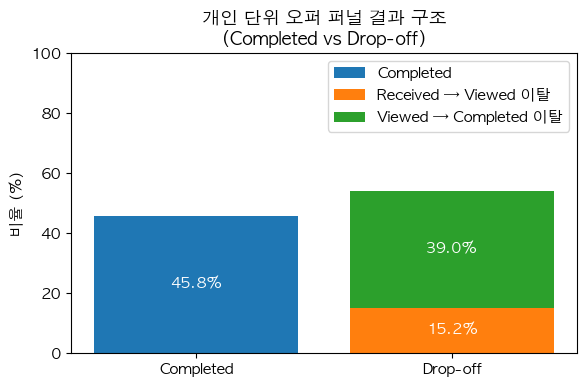

In [31]:
import matplotlib.pyplot as plt

# 비율 (%)
completed = 45.8
drop_total = 54.2
drop_rv = 15.2   # Received → Viewed 이탈
drop_vc = 39.0   # Viewed → Completed 이탈

labels = ["Completed", "Drop-off"]
x = range(len(labels))

plt.figure(figsize=(6, 4))

# Completed 단일 막대
plt.bar(
    x[0],
    completed,
    label="Completed",
)

# Drop-off 스택 막대
plt.bar(
    x[1],
    drop_rv,
    label="Received → Viewed 이탈",
)

plt.bar(
    x[1],
    drop_vc,
    bottom=drop_rv,
    label="Viewed → Completed 이탈",
)

# 수치 라벨
plt.text(x[0], completed / 2, f"{completed}%", ha="center", va="center", color="white", fontweight="bold")

plt.text(x[1], drop_rv / 2, f"{drop_rv}%", ha="center", va="center", color="white", fontweight="bold")
plt.text(x[1], drop_rv + drop_vc / 2, f"{drop_vc}%", ha="center", va="center", color="white", fontweight="bold")

# 축/제목
plt.xticks(x, labels)
plt.ylabel("비율 (%)")
plt.ylim(0, 100)
plt.title("개인 단위 오퍼 퍼널 결과 구조\n(Completed vs Drop-off)")
plt.legend()
plt.tight_layout()
plt.show()

### 7.3 개인 단위 오퍼 퍼널 이탈 분포 정의

본 분석은 **이벤트 발생 횟수**가 아닌,  
**개인(person)–오퍼(offer) 단위**를 기준으로  
각 오퍼가 **최종적으로 어떤 상태로 종료되었는지**를 분류한 결과이다.

즉, 본 분석은 다음 질문에 기반한다.

> **“한 고객이 하나의 오퍼를 받았을 때,  
> 그 오퍼는 퍼널의 어느 지점에서 종료되었는가?”**

이를 위해 동일한 **고객–오퍼 조합**에 대해  
`offer received`, `offer viewed`, `offer completed` 이벤트의  
**존재 여부(Boolean)** 를 기준으로 퍼널 통과 여부를 정의하였다.

---

#### 🔹 Drop-off Stage 정의

#### 1️⃣ Received → Viewed 이탈
- **정의**
  - 오퍼를 수신했으나 한 번도 열어보지 않은 경우
- **해석 의미**
  - 오퍼 노출 타이밍 부적합
  - 전달 채널 또는 메시지 매력도 부족
  - 고객 관심도와 오퍼 주제의 불일치

---

##### 2️⃣ Viewed → Completed 이탈
- **정의**
  - 오퍼를 열어보았으나 완료 이벤트가 발생하지 않은 경우
- **해석 의미**
  - 조건 난이도 대비 보상 매력 부족
  - 사용 맥락(시간·상황) 부적합
  - 행동 전환(Conversion) 설계 실패

---

##### 3️⃣ Completed
- **정의**
  - 오퍼를 수신한 후 **최종적으로 완료 이벤트가 발생한 경우**
- **주의 사항**
  - 본 분류에는 **조회 여부와 관계없이 완료된 경우**가 포함됨
  - 즉, `Received → Completed`  
    (Viewed 없이 바로 완료) 케이스도 포함된 **최종 성공 상태**
- **해석 의미**
  - 오퍼 조건, 고객 니즈, 사용 타이밍 중  
    **최소 하나 이상이 충분히 맞아떨어진 경우**

---

#### 🔹 핵심 해석

- 오퍼를 **열어본 이후(Viewed)** 의 고객 행동은
  - 약 절반은 **최종 완료**로 이어지고
  - 나머지 절반은 **중간에서 이탈**하는 구조를 보인다.
- 즉, **Viewed 단계는 오퍼 반응의 명확한 분기점**으로 작동한다.

---
### 7.4 성별과 이탈단계



In [32]:
person_offer_profile['gender'].value_counts(dropna=False)

gender
M       31645
F       22808
None     8066
O         769
Name: count, dtype: int64

✅ (1) O(Other)는 분석 변수로 부적합
	•	표본 수 769 → 통계적으로 매우 불안정
	•	이탈률이 조금만 튀어도 “의미 있어 보이는 착시” 발생
	•	→ 제외가 정석

✅ (2) 결측(NaN)은 ‘의미 있는 집단’이 아님
	•	성별 미입력 = 행동/심리 해석 불가
	•	NaN 자체가 “성별 특성”을 설명하지 않음
	•	→ 성별 분석에서는 제외, 전체 분석에서는 유지 가능

✅ (3) M/F는 충분한 표본
	•	수만 단위 → 비교 분석 가능
	•	다만: 핵심 설명 변수는 아님

In [33]:
#남여로만 클린 데이터로 분석
gender_clean = person_offer_profile[
    person_offer_profile['gender'].isin(['M', 'F'])
]


In [34]:
gender_dropoff = (
    gender_clean          # ✅ 여기만 바뀜
    .groupby('gender')['dropoff_stage']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index(name='percentage')
)

gender_dropoff

,gender,dropoff_stage,percentage
0,F,Completed,58.1
1,F,Viewed → Completed 이탈,29.5
2,F,Received → Viewed 이탈,12.4
3,M,Completed,45.0
4,M,Viewed → Completed 이탈,37.9
5,M,Received → Viewed 이탈,17.0


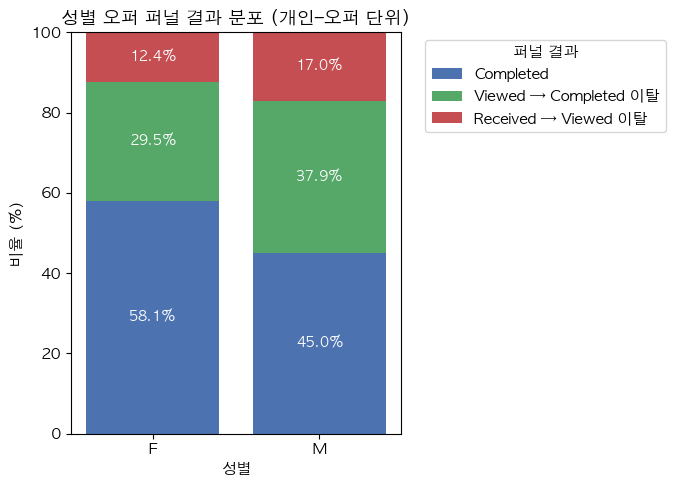

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# 피벗 형태로 변환 (시각화용)
gender_pivot = (
    gender_dropoff
    .pivot(index='gender', columns='dropoff_stage', values='percentage')
    .reindex(columns=[
        'Completed',
        'Viewed → Completed 이탈',
        'Received → Viewed 이탈'
    ])
)

# 시각화
plt.figure(figsize=(7, 5))

bottom = pd.Series([0, 0], index=gender_pivot.index)

colors = {
    'Completed': '#4C72B0',
    'Viewed → Completed 이탈': '#55A868',
    'Received → Viewed 이탈': '#C44E52'
}

for stage in gender_pivot.columns:
    plt.bar(
        gender_pivot.index,
        gender_pivot[stage],
        bottom=bottom,
        label=stage,
        color=colors[stage]
    )
    bottom += gender_pivot[stage]

# 값 라벨 표시
for i, gender in enumerate(gender_pivot.index):
    cum = 0
    for stage in gender_pivot.columns:
        val = gender_pivot.loc[gender, stage]
        plt.text(i, cum + val / 2, f"{val:.1f}%", ha='center', va='center', color='white', fontsize=10)
        cum += val

plt.title('성별 오퍼 퍼널 결과 분포 (개인–오퍼 단위)')
plt.xlabel('성별')
plt.ylabel('비율 (%)')
plt.ylim(0, 100)
plt.legend(title='퍼널 결과', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 📊 7.4 성별별 오퍼 단계 이탈 분포 분석 (개인–오퍼 단위)

분석 목적

본 분석은 고객의 **성별(F / M)**에 따라
오퍼 라이프사이클(수신 → 조회 → 완료)에서
어느 단계에서 이탈이 발생하는지, 그리고 그 비중이 어떻게 다른지를 파악하기 위함임

-> 동일한 오퍼가 모든 고객군에게 동일한 전환 구조를 보이는지?

⸻

분석 기준
	•	분석 단위: 개인(person)–오퍼(offer) 단위
	•	각 오퍼는 다음 중 하나의 상태로 분류됨
	•	Completed
	•	Viewed → Completed 이탈
	•	Received → Viewed 이탈
	•	성별은 M / F만 포함하여 분석
(결측치 및 기타(O)는 해석 안정성을 위해 제외)

⸻

분석 결과 요약
	•	성별에 따라 퍼널 최종 결과 분포에 차이가 관찰된다.
	•	여성(F) 고객군은 오퍼 완료(Completed) 비중이 상대적으로 높다.
	•	남성(M) 고객군은 오퍼를 조회(Viewed)한 이후
완료 단계로 이어지지 못하는 비율이 더 높게 나타난다.

⸻

단계별 분포 비교

🔹 여성(F)
	•	Completed: 58.1%
	•	Viewed → Completed 이탈: 29.5%
	•	Received → Viewed 이탈: 12.4%

→ 오퍼를 조회한 이후 완료로 이어질 확률이 상대적으로 높음

🔹 남성(M)
	•	Completed: 45.0%
	•	Viewed → Completed 이탈: 37.9%
	•	Received → Viewed 이탈: 17.0%

→ 오퍼를 인지(Viewed)했음에도
행동 전환(완료) 단계에서 멈추는 비율이 더 큼

⸻

핵심 해석
	•	성별에 따라 Viewed 이후 행동 전환 구조가 다르게 나타남
	•	특히 남성 고객군에서는
오퍼 조회 이후 완료로 이어지지 않는 비중이 높아,
Viewed → Completed 구간이 상대적으로 취약한 병목 지점으로 작동함
	•	다만, 성별 단독으로는 이탈의 주된 원인이라기보다는
다른 요인(조건 난이도, 소득, 신규 여부 등)과 결합될 때 의미가 커질 가능성이 높음

⸻

시사점
	•	단일 오퍼 설계가 성별에 관계없이 동일한 전환 효과를 낸다고 보기 어렵다.
	•	특히 조회 이후 이탈 비중이 높은 고객군에 대해서는
	•	오퍼 조건 난이도
	•	보상 구조
	•	행동 유도 설계(UI/UX)
를 중심으로 한 추가적인 세분화 전략이 필요하다.
	•	성별은 주요 실패 원인이라기보다는 보조적 설명 변수로 활용하는 것이 적절하다.

---
### 7.5 연령대별 이탈 분석

In [36]:
### age_group 결측 확인

person_offer_profile['age_group'].value_counts(dropna=False)

age_group
65+      14744
55-64    12593
45-54    11597
NaN       8084
35-44     7335
25-34     5147
<25       3788
Name: count, dtype: int64

### 연령대(age_group) 결측에 대한 처리 기준

본 데이터셋에서 age 값이 118로 기록된 경우는  
고객이 연령 정보를 제공하지 않은 경우를 의미한다.

이에 따라 age_group 생성 시 해당 고객들은 결측(Missing)으로 분류되었으며,  
이는 데이터 오류가 아닌 **의도된 구조적 결측**으로 판단하였다.

본 단계의 목적은 연령대가 명확한 고객 간의  
오퍼 반응 및 이탈 패턴 비교이므로,  
연령대 분석에서는 age_group이 결측인 고객을 제외하고 분석을 진행하였다.

In [37]:
# 연령대별 이탈 분포
age_dropoff = (
    person_offer_profile
    .dropna(subset=['age_group'])
    .groupby('age_group')['dropoff_stage']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index(name='percentage')
)

age_dropoff

/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_4258/1794320556.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_group')['dropoff_stage']


,age_group,dropoff_stage,percentage
0,<25,Viewed → Completed 이탈,39.7
1,<25,Completed,38.9
2,<25,Received → Viewed 이탈,21.3
3,25-34,Completed,42.0
4,25-34,Viewed → Completed 이탈,36.9
5,25-34,Received → Viewed 이탈,21.1
6,35-44,Completed,48.6
7,35-44,Viewed → Completed 이탈,37.1
8,35-44,Received → Viewed 이탈,14.3
9,45-54,Completed,52.5


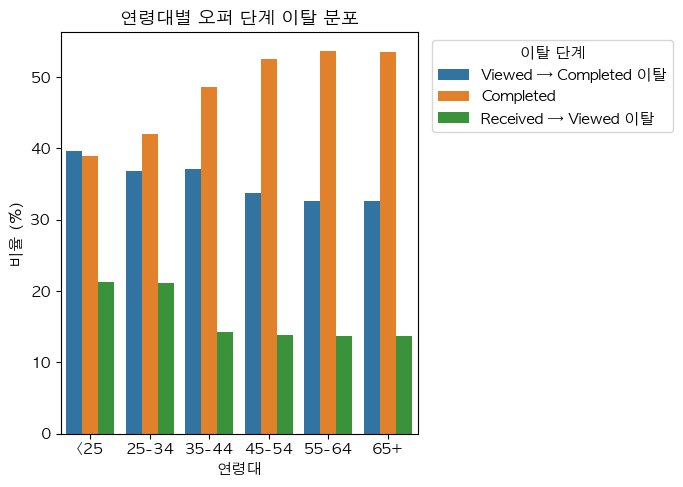

In [38]:
# 연령대별 오퍼 이탈 분포 시각화
plt.figure(figsize=(7,5))
sns.barplot(
    data=age_dropoff,
    x='age_group',
    y='percentage',
    hue='dropoff_stage'
)

plt.title('연령대별 오퍼 단계 이탈 분포')
plt.xlabel('연령대')
plt.ylabel('비율 (%)')
plt.legend(title='이탈 단계', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

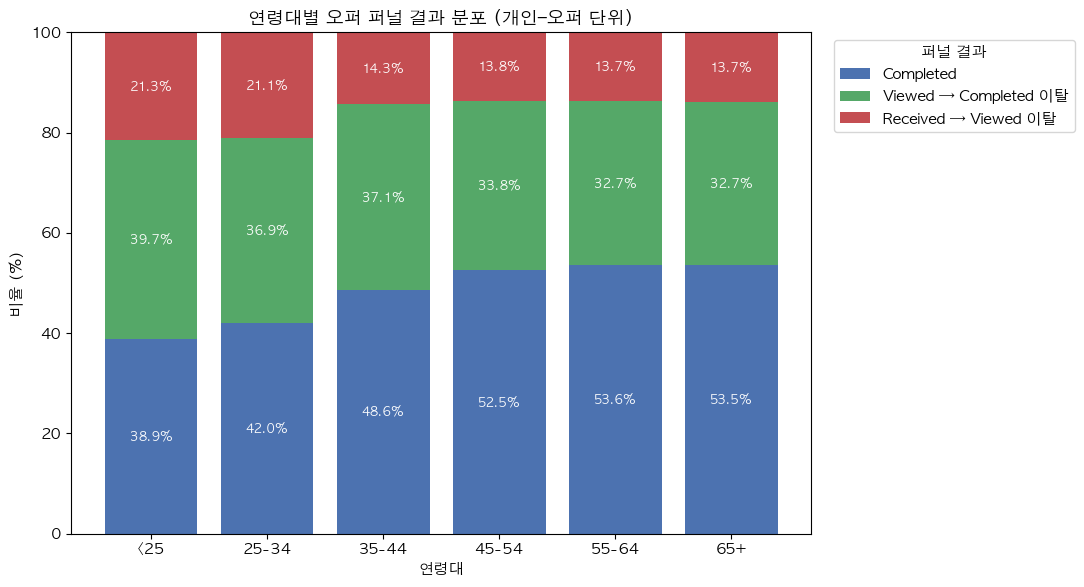

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 피벗 테이블 생성
age_pivot = age_dropoff.pivot(
    index='age_group',
    columns='dropoff_stage',
    values='percentage'
).fillna(0)

# 단계 순서 고정
stage_order = ['Completed', 'Viewed → Completed 이탈', 'Received → Viewed 이탈']
age_pivot = age_pivot[stage_order]

# 색상 정의 (기존 차트와 동일)
colors = {
    'Completed': '#4C72B0',
    'Viewed → Completed 이탈': '#55A868',
    'Received → Viewed 이탈': '#C44E52'
}

# 스택 막대 그래프
plt.figure(figsize=(11, 6))
bottom = np.zeros(len(age_pivot))

for stage in stage_order:
    plt.bar(
        age_pivot.index,
        age_pivot[stage],
        bottom=bottom,
        label=stage,
        color=colors[stage]
    )
    
    # 수치 표시
    for i, val in enumerate(age_pivot[stage]):
        if val > 5:
            plt.text(
                i,
                bottom[i] + val / 2,
                f"{val:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='white'
            )
    bottom += age_pivot[stage].values

plt.title('연령대별 오퍼 퍼널 결과 분포 (개인–오퍼 단위)', fontsize=13)
plt.xlabel('연령대')
plt.ylabel('비율 (%)')
plt.ylim(0, 100)
plt.legend(title='퍼널 결과', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

앞선 연령대별 오퍼 이탈 분포 시각화를 보다 명확히 해석하기 위해,
Viewed → Completed 단계 이탈 비율을 연령대별로 비교하였다.

그 결과, 25세 미만(<25) 고객군에서 해당 이탈 비율이 39.7%로 가장 높게 나타났으며,
25–34세(36.9%), 35–44세(37.1%) 연령대에서도 유사한 수준의 이탈이 관찰되었다.

이는 오퍼를 인지한 이후 실제 행동으로 전환되는 과정에서
젊은 연령대일수록 상대적으로 더 큰 마찰이 존재함을 시사한다.

### 7.5 📊 연령대별 오퍼 단계 이탈 분석

#### 분석 목적
본 분석은 고객의 연령대에 따라  
오퍼 퍼널(Received → Viewed → Completed)에서  
이탈이 발생하는 지점과 비중이 어떻게 달라지는지를 확인하기 위해 수행되었다.

이를 통해 연령대별로  
오퍼 조건과 보상 구조가 동일하게 작동하는지 검증한다.

---

#### 핵심 결과 요약
- 연령이 낮을수록 **Completed 비율은 낮고**,  
  **Viewed → Completed 이탈 비율은 높게** 나타난다.
- 연령이 높아질수록 **Completed 비율이 점진적으로 증가**하는 패턴이 관찰된다.
- 모든 연령대에서 **가장 큰 병목은 Viewed → Completed 단계**로 일관된다.

---

#### 연령대별 구조적 패턴
- **젊은 연령대 (<25, 25–34)**  
  - 오퍼를 조회(Viewed)한 이후  
    완료로 이어지지 못하는 비중이 가장 큼  
  - 오퍼 인지 이후 행동 전환에 실패하는 구조

- **중·장년층 (35–44 이상)**  
  - Completed 비율이 뚜렷하게 높아짐  
  - 오퍼 조건과 기대 수준이 비교적 잘 맞는 집단으로 해석 가능

---

#### 단계별 해석
- **Received → Viewed 이탈**  
  - 연령대별 큰 차이는 없음  
  - 오퍼 노출 자체는 핵심 문제가 아님을 시사

- **Viewed → Completed 이탈 (핵심 병목)**  
  - 특히 젊은 연령대에서 집중적으로 발생  
  - 조건 난이도, 보상 즉시성, 실행 장벽 가능성 시사

- **Completed**  
  - 연령이 높아질수록 비율 증가  
  - 오퍼가 중·장년층에게 더 효과적으로 작동함을 의미

---

#### 시사점
- 오퍼 이탈은 연령에 따라 **구조적으로 다른 양상**을 보인다.
- 특히 젊은 연령대에서는  
  `오퍼 인지 → 행동 전환` 구간을 낮춰주는 설계가 필요하다.
  - 예: 조건 단순화, 즉각적 보상, 진입 장벽 완화
- 연령은 단순한 고객 특성이 아니라  
  **오퍼 설계 방식을 달리해야 하는 핵심 축**으로 해석하는 것이 적절하다.

---

### 다음 분석 연결
연령대별 이탈 구조를 바탕으로,  
소득 수준(income_group)과 결합하여  
이탈 패턴이 경제적 요인에 의해 강화되는지 추가 분석한다.

---
### 7.6 소득 수준과 이탈률 분석

In [29]:
#먼저 income_group 이 제대로 만들어졌나 확인
person_offer_profile['income'].isna().mean()
person_offer_profile['income'].describe()
person_offer_profile['income_group'].value_counts(dropna=False)

income_group
Mid-High    14317
Low         14076
Mid-Low     13536
High        13293
NaN          8066
Name: count, dtype: int64

### 소득 구간 생성 결과 검증

- 고객의 연소득(income)을 기준으로 4분위(qcut) 기반 소득 구간을 생성하였다.
- 각 소득 구간(Low, Mid-Low, Mid-High, High)은 비교적 균등한 분포를 보이며,
  이는 분위수 기반 구간화가 정상적으로 수행되었음을 의미한다.
- 전체 고객 중 일부는 income 정보가 결측(Missing)으로 존재하였으며,
  이는 원본 데이터의 특성으로 판단된다.
- 이후 소득 수준별 이탈 분석에서는 income_group이 존재하는 고객만을 대상으로 분석을 진행한다.

In [45]:
# 소득 정보가 있는 고객만 사용
income_clean = person_offer_profile.dropna(subset=['income_group'])

In [46]:
#개인-오퍼 단위 이탈 분포
income_dropoff = (
    income_clean
    .groupby('income_group')['dropoff_stage']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index(name='percentage')
)

income_dropoff

/var/folders/dl/2hxyxgtd0vbcrnl54xbdbz7h0000gn/T/ipykernel_4258/1524319041.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('income_group')['dropoff_stage']


,income_group,dropoff_stage,percentage
0,Low,Viewed → Completed 이탈,40.1
1,Low,Completed,37.4
2,Low,Received → Viewed 이탈,22.5
3,Mid-Low,Completed,47.6
4,Mid-Low,Viewed → Completed 이탈,37.9
5,Mid-Low,Received → Viewed 이탈,14.4
6,Mid-High,Completed,54.7
7,Mid-High,Viewed → Completed 이탈,32.6
8,Mid-High,Received → Viewed 이탈,12.7
9,High,Completed,63.2


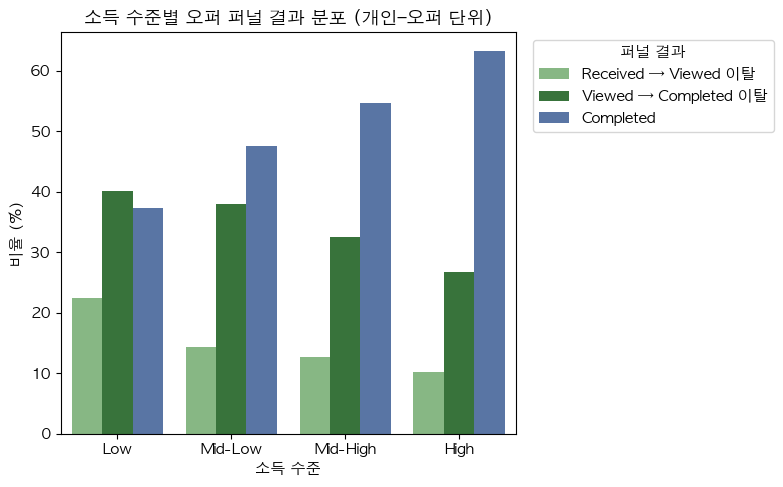

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 퍼널 결과 순서 고정
stage_order = [
    'Received → Viewed 이탈',
    'Viewed → Completed 이탈',
    'Completed'
]

# 색상 지정 (이탈 = 녹색 계열, 완료 = 파랑)
palette = {
    'Received → Viewed 이탈': '#7FBF7B',   # 연한 녹색
    'Viewed → Completed 이탈': '#2E7D32',  # 진한 녹색
    'Completed': '#4C72B0'                  # 파랑
}

plt.figure(figsize=(8,5))
sns.barplot(
    data=income_dropoff,
    x='income_group',
    y='percentage',
    hue='dropoff_stage',
    hue_order=stage_order,
    palette=palette
)

plt.title('소득 수준별 오퍼 퍼널 결과 분포 (개인–오퍼 단위)')
plt.xlabel('소득 수준')
plt.ylabel('비율 (%)')
plt.legend(title='퍼널 결과', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7.6 📊 소득 수준별 오퍼 퍼널 이탈 분석

### 분석 목적
고객의 **소득 수준(income_group)** 에 따라  
오퍼 퍼널(Received → Viewed → Completed)에서  
이탈 구조가 어떻게 달라지는지를 확인한다.  
(분석 단위: 개인–오퍼 기준)

---

### 핵심 결과 요약
- 소득 수준이 높아질수록 **오퍼 완료(Completed) 비율은 증가**
- 소득 수준이 낮을수록 **Viewed → Completed 단계 이탈 비중이 높음**
- Received → Viewed 이탈은 전 구간에서 점진적으로 감소

---

### 단계별 해석

**① Received → Viewed 이탈**
- 저소득층에서 상대적으로 높은 비중
- 오퍼 초기 관심 형성 단계에서 소득별 차이 존재

**② Viewed → Completed 이탈 (주요 병목)**
- 저소득층에서 가장 크게 발생
- 조건 부담, 보상 매력 부족 가능성 시사

**③ Completed**
- 고소득층으로 갈수록 비율이 뚜렷하게 증가
- 오퍼 조건을 실제 행동으로 전환할 여력 존재

---

### 시사점
- 오퍼 실패는 무작위가 아니라 **소득 수준에 따라 구조적으로 발생**
- 특히 **Viewed 이후 전환 단계**에서 소득별 격차가 가장 큼
- 저소득층 대상 오퍼는 조건 완화 및 진입 장벽 감소가 핵심 개선 포인트

---
### 8. 가입 시점 기반 이탈 분석 


In [55]:
#8.1 가입 시점 변수 준비
profile = pd.read_json(
    '../data/raw/profile.json',
    orient='records',
    lines=True
)

profile = profile[['id', 'became_member_on']]
profile.head()

,id,became_member_on
0,68be06ca386d4c31939f3a4f0e3dd783,20170212
1,0610b486422d4921ae7d2bf64640c50b,20170715
2,38fe809add3b4fcf9315a9694bb96ff5,20180712
3,78afa995795e4d85b5d9ceeca43f5fef,20170509
4,a03223e636434f42ac4c3df47e8bac43,20170804


In [56]:
#8.2 person_offer_profile에 다시 붙이기
person_offer_profile = person_offer_profile.drop(
    columns=['became_member_on'], errors='ignore'
)

person_offer_profile = person_offer_profile.merge(
    profile,
    left_on='person',
    right_on='id',
    how='left'
)

In [57]:
#8.3 가입일자 datetime 변환
person_offer_profile['became_member_on'] = pd.to_datetime(
    person_offer_profile['became_member_on'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

person_offer_profile[['became_member_on']].head()

,became_member_on
0,2017-04-21
1,2017-04-21
2,2017-04-21
3,2017-04-21
4,2017-04-21


In [58]:
print(person_offer_profile['became_member_on'].nunique())
person_offer_profile['became_member_on'].value_counts().head()

1716


became_member_on
2017-08-19    162
2017-10-07    152
2017-12-07    152
2017-08-15    150
2018-01-25    142
Name: count, dtype: int64

가입일 정보가 1,716개

In [59]:
#가입 cohort 변수 생성
person_offer_profile['join_year'] = (
    person_offer_profile['became_member_on']
    .dt.year
)

# 분포 확인
person_offer_profile['join_year'].value_counts(dropna=False)


join_year
2017    24086
2018    15705
2016    13076
2015     6770
2014     2580
2013     1071
Name: count, dtype: int64

In [60]:
#가입년도별 Viewed → Completed 이탈 비율 분석
cohort_viewed = person_offer_profile[
    person_offer_profile['viewed'] == True
].copy()

cohort_drop = (
    cohort_viewed
    .groupby('join_year')['completed']
    .mean()
    .rsub(1)
    .mul(100)
    .round(1)
    .reset_index(name='viewed_to_completed_drop_rate')
)

display(
    cohort_drop.sort_values(
        'viewed_to_completed_drop_rate',
        ascending=False
    )
)
print("Viewed 표본 수:", len(cohort_viewed))

,join_year,viewed_to_completed_drop_rate
5,2018,66.6
4,2017,51.1
1,2014,48.9
0,2013,48.2
2,2015,38.9
3,2016,35.6


Viewed 표본 수: 49135


In [61]:
# 1) join_year 기준 정렬 (필수)
cohort_drop = cohort_drop.sort_values('join_year')

# 2) 보기 좋게 타입 정리 (선택)
cohort_drop['join_year'] = cohort_drop['join_year'].astype(int)

display(cohort_drop)

,join_year,viewed_to_completed_drop_rate
0,2013,48.2
1,2014,48.9
2,2015,38.9
3,2016,35.6
4,2017,51.1
5,2018,66.6


#### 시각화 차트 에러나서 04_join_cohort_chart 노트북에서 따로 그리기로 함. 


본 분석은 고객–오퍼 단위(person × offer)를 기준으로,
가입 연도별로 오퍼를 조회(Viewed)한 이후
완료(Completed)로 이어지지 못한 비율을 이탈률로 정의하였다.

그 결과, 가입 시점이 최근일수록
Viewed → Completed 구간에서의 이탈률이
유의미하게 증가하는 패턴이 확인되었다.
특히 2018년 가입 고객의 이탈률은 66.6%로,
2016년 가입 고객(35.6%) 대비 약 2배 수준에 달한다.

이는 오퍼 인지 이후 실제 행동으로 전환되는 과정에서
고객의 서비스 이용 경험 수준 또는
오퍼 이해도가 중요한 구조적 요인으로 작용할 가능성을 시사하며,
앞선 연령 및 소득 분석에서 관찰된 이탈 패턴이
가입 시점에 따른 경험 차이에 의해
일부 설명될 수 있음을 보여준다.

